<div align="center">

# Universidad de Sevilla  
## Grado en Ingeniería del Software  
### Escuela Técnica Superior de Ingeniería Informática  
### Inteligencia Artificial (IA) – Curso 2024/2025  

<img src="../../img/portada.png" width="300"/>

---

#  Ensamble Secuencial de Modelos Predictivos  
### Primera Convocatoria – Junio 2025  

**Profesor:** Juan Galán Páez  
**Autores:**  
Carlos Martín de Prado Barragán  
Marco Padilla Gómez  

**Fecha de entrega:** 9 de Junio de 2025  

</div>

## Introducción

El objetivo de este notebook es implementar y evaluar un meta-modelo de ensamble secuencial para tareas de regresión, utilizando el conjunto de datos  que contiene informacion sobre viviendas que han sido vendidas a traves de una agencia inmobiliaria.

Este tipo de modelo se construye mediante la combinación iterativa de varios modelos base, donde cada nuevo modelo aprende a corregir los errores residuales cometidos por los anteriores, lo que permite mejorar la capacidad predictiva y la generalización.

Se emplea el `LinearRegression` como modelo base por su interpretabilidad y capacidad de establecer una línea base para comparación. Además, se utilizan técnicas de preprocesamiento como la estandarización de variables para normalizar las escalas y facilitar el entrenamiento.

La evaluación inicial se realiza mediante la métrica de coeficiente de determinación R² sobre un conjunto de prueba, que mide la proporción de variabilidad explicada por el modelo. En notebooks posteriores se implementará validación cruzada para evaluar la estabilidad y robustez del modelo.

Este enfoque está inspirado en técnicas de boosting y proporciona un marco flexible y escalable para resolver problemas de regresión complejos.

## 1. Importación de librerías

En esta sección se importan las librerías necesarias para la implementación del meta-modelo secuencial:

- `numpy` y `pandas` para manipulación de datos.
- `LinearRegression` desde `sklearn.linear_model`, que se utilizará como modelo base en el ensamblador.
- `StandardScaler` y `OneHotEncoder` para estandarización de características.
- `train_test_split` para dividir el conjunto de datos en entrenamiento y prueba.
- `r2_score` para evaluar el rendimiento del modelo con la métrica R².
- Transformación de las columnas(`ColumnTransformer`)

También se añade la ruta al módulo local que contiene la clase `SequentialEnsembleRegressor`, implementada previamente para permitir su importación.

In [1]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer

# Importar el meta-modelo desde nuestro módulo
import sys
sys.path.append('../../src')  # Ajusta esta ruta según tu estructura
from sequential_ensemble import SequentialEnsembleRegressor

## 2. Carga y exploración inicial del dataset

En esta sección se carga el conjunto de datos `house_prices.csv` desde la carpeta `data`.  
A continuación, se muestra información general del DataFrame, incluyendo:

- El número de filas y columnas.
- El tipo de datos de cada columna.
- Los primeros registros del conjunto para una inspección visual rápida.

In [2]:
# Cargar el dataset desde la carpeta 'data'
df = pd.read_csv("../../data/house_prices.csv")

# Mostrar información general
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   GarageCars     560 non-null    int64  
 1   Condition2     560 non-null    object 
 2   YearBuilt      560 non-null    int64  
 3   GarageYrBlt    560 non-null    float64
 4   LandContour    560 non-null    object 
 5   LowQualFinSF   560 non-null    int64  
 6   HouseStyle     560 non-null    object 
 7   GarageType     560 non-null    object 
 8   MSSubClass     560 non-null    int64  
 9   WoodDeckSF     560 non-null    int64  
 10  FireplaceQu    560 non-null    object 
 11  BsmtFinSF2     560 non-null    int64  
 12  Alley          560 non-null    object 
 13  MSZoning       560 non-null    object 
 14  OverallCond    560 non-null    int64  
 15  EnclosedPorch  560 non-null    int64  
 16  CentralAir     560 non-null    object 
 17  LotFrontage    560 non-null    float64
 18  GarageCond

,GarageCars,Condition2,YearBuilt,GarageYrBlt,LandContour,LowQualFinSF,HouseStyle,GarageType,MSSubClass,WoodDeckSF,...,MiscVal,BsmtExposure,OpenPorchSF,ExterCond,Fireplaces,FullBath,BsmtQual,MiscFeature,PoolQC,SalePrice
0,2,Norm,1962,1977.0,Lvl,0,1Story,Detchd,20,0,...,0,none,0,TA,0,1,TA,none,none,132000
1,0,Norm,1914,0.0,Lvl,0,2.5Unf,none,75,0,...,0,none,291,TA,1,2,TA,none,none,128000
2,2,Norm,1999,1999.0,Lvl,0,1Story,Attchd,20,0,...,0,Av,35,TA,0,2,Gd,none,none,192000
3,1,Norm,1948,1948.0,Bnk,0,2Story,Attchd,20,103,...,0,none,0,Gd,0,3,TA,none,none,225000
4,2,Norm,1950,1950.0,Lvl,0,1Story,Detchd,20,0,...,0,none,29,TA,0,1,none,none,none,109900


## 3. Preprocesamiento de los datos

En este paso se realiza la preparación de los datos para el entrenamiento del meta-modelo:

- Se separan las variables predictoras (`X`) y la variable objetivo (`y`), que en este caso es `SalePrice`.
- Las variables numéricas se estandarizan utilizando `StandardScaler`, que normaliza los valores para que tengan media 0 y desviación estándar 1, mejorando así el rendimiento y estabilidad del modelo.
- Las variables categóricas presentes en el conjunto de datos (`object`) se codifican numéricamente mediante `OneHotEncoder`, creando columnas binarias para cada categoría.
- El conjunto de datos estandarizado se divide en conjuntos de entrenamiento (80%) y prueba (20%) mediante `train_test_split`, asegurando una evaluación objetiva del modelo.
- Se convierte `y_train` a un array de NumPy para evitar problemas de indexación con pandas durante el entrenamiento del meta-modelo.

In [3]:
# Separar variables predictoras y variable objetivo
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Detectar variables categóricas (tipo objeto) y numéricas
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])
X_processed = preprocessor.fit_transform(X)

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Evitar errores de indexación
y_train = y_train.to_numpy()

## 4. Creación y entrenamiento del meta-modelo secuencial

Se instancia el meta-modelo `SequentialEnsembleRegressor` utilizando `LinearRegression` como estimador base. Los hiperparámetros seleccionados para esta configuración son:

- `n_estimators=200`: se entrenan 200 modelos secuenciales.
- `lr=0.5`: tasa de aprendizaje que pondera la contribución de cada modelo.
- `sample_size=1`: se usa el 100% del conjunto de entrenamiento en cada iteración.
- `random_state=42`: semilla para asegurar la reproducibilidad.

Una vez configurado, se entrena el meta-modelo sobre el conjunto de entrenamiento mediante el método `.fit()`. Durante este proceso, cada nuevo modelo intenta predecir los residuos (errores) del modelo anterior, mejorando progresivamente el rendimiento global.


In [4]:
# Crear y entrenar el meta-modelo con LinearRegression
modelo = SequentialEnsembleRegressor(
    base_estimator=LinearRegression,
    n_estimators=200,
    lr=0.5,
    sample_size=1,
    est_params={},
    random_state=42
)

# Entrenamiento del modelo
modelo.fit(X_train, y_train)

SequentialEnsembleRegressor(base_estimator=<class 'sklearn.linear_model._base.LinearRegression'>,
                            est_params={}, lr=0.5, n_estimators=200,
                            random_state=42, sample_size=1)

## 5. Predicción y evaluación del modelo

En esta última sección se generan las predicciones del meta-modelo sobre el conjunto de prueba (`X_test`).  
A continuación, se evalúa la calidad de las predicciones calculando el coeficiente de determinación R², que mide qué proporción de la variabilidad en la variable objetivo es explicada por el modelo.

Un valor de R² cercano a 1 indica un buen ajuste del modelo a los datos de prueba.

In [5]:
# Generar predicciones
y_pred = modelo.predict(X_test)

# Evaluar con el método score() para simplicidad
r2 = modelo.score(X_test, y_test)
print(f"R² en test: {r2:.4f}")
print("El modelo explica el {:.2f}% de la variabilidad de los datos de prueba.".format(r2 * 100))

R² en test: 0.7902
El modelo explica el 79.02% de la variabilidad de los datos de prueba.


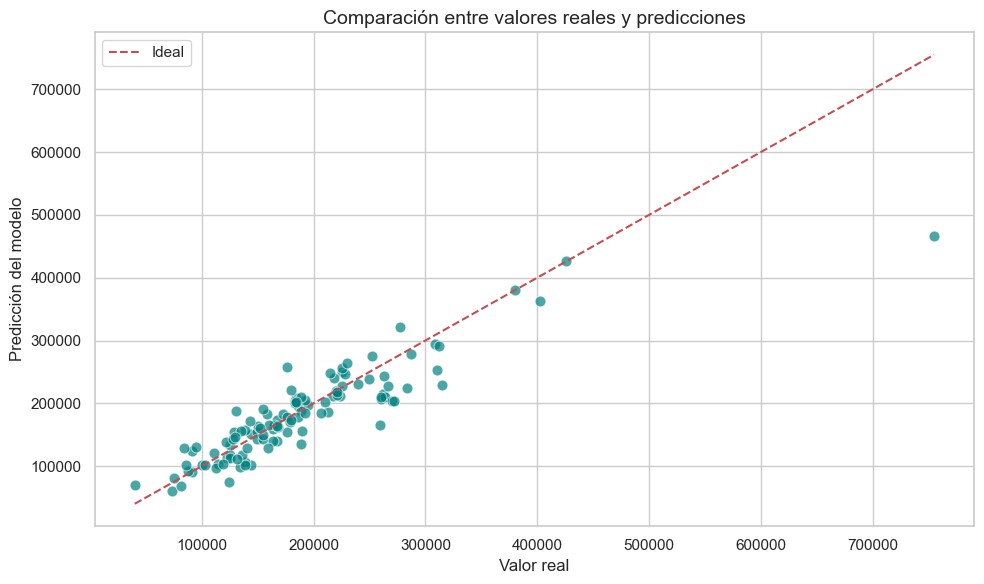

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear DataFrame para comparar fácilmente
df_resultados = pd.DataFrame({
    "Real": y_test,
    "Predicción": y_pred
})

# Estilo visual
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Gráfico de dispersión con línea de referencia
sns.scatterplot(data=df_resultados, x="Real", y="Predicción", alpha=0.7, color="teal", s=60)
plt.plot([df_resultados.min().min(), df_resultados.max().max()],
         [df_resultados.min().min(), df_resultados.max().max()],
         'r--', label="Ideal")

plt.title("Comparación entre valores reales y predicciones", fontsize=14)
plt.xlabel("Valor real", fontsize=12)
plt.ylabel("Predicción del modelo", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
#Mostrar 10 ejemplos reales vs predicciones
df_predicciones = pd.DataFrame({
    'Valor real': y_test,
    'Predicción': y_pred
})

df_predicciones.head(10)

,Valor real,Predicción
453,143750,150722.404446
341,263000,244292.082132
177,167240,173357.944359
86,172400,183170.812920
332,91000,90728.658960
140,149500,154480.401942
272,125500,133015.012908
296,144000,101188.251122
101,91000,123368.077971
518,262280,214513.814307


## 6. Conclusiones

Los resultados obtenidos tras aplicar un modelo de regresión lineal(`LinearRegression`) al conjunto de datos `house_prices.csv` reflejan un rendimiento notablemente sólido:

El modelo alcanzó un coeficiente de determinación **R² de 0.7902** sobre el conjunto de prueba, lo que indica que **es capaz de explicar aproximadamente el 79% de la variabilidad** en los precios de venta de las viviendas.

Este resultado sugiere que la relación entre las variables predictoras (como el número de garajes, el año de construcción, la calidad exterior, etc.) y la variable objetivo (`SalePrice`) **es en gran parte lineal**, o al menos, **aproximadamente lineal**.

La calidad de los datos, junto con un preprocesamiento adecuado (estandarización + codificación de variables categóricas), ha permitido que un modelo tan sencillo como la regresión lineal obtenga **un buen rendimiento** mejor incluso que el de los arboles de decisión.

La comparación gráfica entre las predicciones del modelo y los valores reales en el conjunto de prueba muestra una tendencia clara a seguir la diagonal ideal (*y = x*), confirmando una buena capacidad predictiva. La mayoría de los puntos se agrupan cerca de esta línea, lo que indica un bajo error de predicción en muchos casos.

Además, la tabla con los ejemplos reales y sus correspondientes predicciones permite comprobar numéricamente la proximidad entre ambos valores, reforzando visualmente la consistencia del modelo.

La regresión lineal ha resultado ser una **buena línea base** para este problema, fácil de interpretar y eficiente, pero con posibilidad de mejora si se usan técnicas de aprendizaje más avanzadas.
